In [ ]:
!pip install -q langchain langchain-google-genai google-generativeai
!pip install -q langchain_community faiss-cpu langchain-text-splitters pymupdf
!pip install -q langgraph

In [ ]:
pip show langchain langchain-google-genai google-generativeai langchain-community faiss-cpu langchain-text-splitters pymupdf langgraph


Name: langchain
Version: 1.3.11
Summary: Building applications with LLMs through composability
Home-page: https://docs.langchain.com/
Author: 
Author-email: 
License: MIT
Location: /usr/local/lib/python3.12/dist-packages
Requires: langchain-core, langgraph, pydantic
Required-by: 
---
Name: langchain-google-genai
Version: 4.2.7
Summary: An integration package connecting Google's genai package and LangChain
Home-page: https://docs.langchain.com/oss/python/integrations/providers/google
Author: 
Author-email: 
License: MIT
Location: /usr/local/lib/python3.12/dist-packages
Requires: filetype, google-genai, langchain-core, pydantic
Required-by: 
---
Name: google-generativeai
Version: 0.8.6
Summary: Google Generative AI High level API client library and tools.
Home-page: https://github.com/google/generative-ai-python
Author: Google LLC
Author-email: googleapis-packages@google.com
License: Apache 2.0
Location: /usr/local/lib/python3.12/dist-packages
Requires: google-ai-generativelanguage, goog

In [ ]:
from google.colab import userdata
GEMINI_API_KEY = userdata.get('GEMINI_API_KEY')

from langchain_google_genai import ChatGoogleGenerativeAI
#"gemini-1.5-pro" "gemini-2.5-flash" "gemini-2.5-flash-lite", "gemini-3.1-flash-lite", "gemini-3-flash"
llm = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash",
    temperature=0,
    google_api_key=GEMINI_API_KEY
)

In [ ]:
PROMPT_TRIAJE = """
Eres un especialista en triaje del Service Desk de la empresa BimBam Buy,
un e-commerce multiplataforma enfocado en la experiencia de compra digital ágil y segura.

Dado el mensaje del usuario, devuelve SÓLO un JSON con:
{
 "decision": "AUTO_RESOLVER" | "PEDIR_INFO" | "ABRIR_TICKET",
 "urgencia": "BAJA" | "MEDIANA" | "ALTA",
 "campos_faltantes": ["..."]
}

Reglas:
- **AUTO_RESOLVER**: Preguntas claras sobre las políticas internas de BimBam Buy
  (Ej.: "¿Cuál es el tiempo estimado de entrega?", "¿Qué cubre la garantía de productos?",
  "¿Cómo funciona el programa de afiliados?", "¿Qué métodos de pago aceptan?").
- **PEDIR_INFO**: Mensajes imprecisos o sin información suficiente para identificar el tema
  (Ej.: "Necesito ayuda con una política", "Tengo una duda general", "No entiendo cómo funciona").
- **ABRIR_TICKET**: Solicitudes de excepciones, autorizaciones, aprobaciones o accesos especiales,
  o cuando el usuario pide explícitamente abrir un ticket
  (Ej.: "Quiero una excepción en el reembolso", "Solicito autorización para un pago especial",
  "Por favor, abre un ticket con soporte de logística").
Analiza el mensaje y decide la acción más adecuada.
"""


In [ ]:
from typing import Literal, List, Dict
from pydantic import BaseModel, Field

class TriajeOut(BaseModel):
  decision: Literal["AUTO_RESOLVER", "PEDIR_INFO", "ABRIR_TICKET"]
  urgencia: Literal["BAJA", "MEDIANA", "ALTA"]
  campos_faltantes: List[str] = Field(default_factory=list)

In [ ]:
from langchain_core.messages import SystemMessage, HumanMessage

chain_de_triaje = llm.with_structured_output(TriajeOut)

def triaje(mensaje: str) -> Dict:
  salida: TriajeOut = chain_de_triaje.invoke(
      [
          SystemMessage(content=PROMPT_TRIAJE),
          HumanMessage(content=mensaje)
      ]
  )
  return salida.model_dump()

In [ ]:
from langchain_core.messages import SystemMessage, HumanMessage
chain_de_triaje = llm.with_structured_output(TriajeOut)

def triaje(mensaje: str) -> Dict:
  salida: TriajeOut = chain_de_triaje.invoke(
     [
         SystemMessage(content=PROMPT_TRIAJE),
          HumanMessage(content=mensaje)
     ]
  )
  return salida.model_dump()

In [ ]:
from pathlib import Path
from langchain_community.document_loaders import PyMuPDFLoader

docs = []

for documento in Path("/content/sample_data/documentos").glob("*.pdf"):
    try:
        loader = PyMuPDFLoader(str(documento))
        docs.extend(loader.load())
        print(f"Archivo cargado: {documento.name}")
    except Exception as e:
        print(f"Error cargando archivo: {documento.name}: {e}")

print(f"Total de documentos cargados: {len(docs)}")

Archivo cargado: Programa de Afiliados de BimBam Buy.pdf
Total de documentos cargados: 11


In [ ]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

splitter = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=100)
docs_splits = splitter.split_documents(docs)

In [ ]:
for chunk in docs_splits:
  print(chunk)
  print("------------------")

page_content='Programa de Afiliados de BimBam Buy
Índice
1. Propósito
2. Alcance
3. Identidad del programa
4. Elegibilidad
5. Funcionamiento general
6. Atribución de ventas
7. Comisiones
8. Pagos a afiliados
9. Retenciones y ajustes
10. Relación con devoluciones y reembolsos
11. Material permitido
12. Material no permitido
13. Comunicación de marca
14. Soporte a afiliados' metadata={'producer': 'iLovePDF', 'creator': '', 'creationdate': '2026-06-16T15:14:26-03:00', 'source': '/content/sample_data/documentos/Programa de Afiliados de BimBam Buy.pdf', 'file_path': '/content/sample_data/documentos/Programa de Afiliados de BimBam Buy.pdf', 'total_pages': 11, 'format': 'PDF 1.6', 'title': '', 'author': '', 'subject': '', 'keywords': '', 'moddate': '2026-06-16T15:46:44-03:00', 'trapped': '', 'modDate': "D:20260616154644-03'00'", 'creationDate': "D:20260616151426-03'00'", 'page': 0}
------------------
page_content='15. Información requerida para soporte
16. Ejemplos operativos
17. Tiempos del 

In [ ]:
from langchain_google_genai import GoogleGenerativeAIEmbeddings
modelo_embeddings = GoogleGenerativeAIEmbeddings(
    model="models/gemini-embedding-001",
    google_api_key=GEMINI_API_KEY
)

In [ ]:
from langchain_community.vectorstores import FAISS

vectorstore = FAISS.from_documents(docs_splits, modelo_embeddings)

retriever = vectorstore.as_retriever(
     search_type="similarity_score_threshold",
     search_kwargs={"score_threshold": 0.3, "k":4}
)

In [ ]:
from langchain_core.prompts import ChatPromptTemplate
from langchain_classic.chains.combine_documents import create_stuff_documents_chain

prompt_rag = ChatPromptTemplate(
    [
        ("system",
            """Eres el especialista en soporte de la empresa BimBam Buy,
            un e-commerce multiplataforma enfocado en la experiencia de compra digital ágil y segura.

            Responde siempre utilizando únicamente la información contenida en el contexto que se te proporcione.

            Si la respuesta está en el contexto, explícalo de forma clara y breve.
            Si la información no aparece en el contexto, responde exactamente: 'No lo sé'.
            No inventes ni supongas información fuera del contexto.
            """
        ),
        ("human", "Contexto: {context}\nPregunta del usuario: {input}")
    ]
)

document_chain = create_stuff_documents_chain(llm, prompt_rag)

In [ ]:
def busqueda_de_respuestas_RAG(pregunta) -> Dict:
  documentos_relacionados = retriever.invoke(pregunta)

  if not documentos_relacionados:
    return {
        "respuesta": "No lo sé",
        "citaciones": [],
        "documentos_encontrados": False
    }
  answer = document_chain.invoke({
    "input": pregunta,
    "context": documentos_relacionados
})
  if answer.rstrip(".!?") == "No lo sé":
    return {
        "respuesta": "No lo sé",
        "citaciones": [],
        "documentos_encontrados": False
    }
  return {
    "respuesta": answer,
    "citaciones": documentos_relacionados,
    "documentos_encontrados": True
}

In [ ]:
r = busqueda_de_respuestas_RAG("¿Cómo se calculan las comisiones?")
print(r)

{'respuesta': 'Las comisiones pueden variar según la categoría de producto, el país, la campaña, el margen y el tipo de afiliado. BimBam Buy puede definir porcentajes diferentes para ciertas líneas o promociones.\n\nLa liquidación de las comisiones puede considerar:\n*   Ventas efectivamente validadas\n*   Cancelaciones\n*   Devoluciones\n*   Reembolsos\n*   Ajustes operativos', 'citaciones': [Document(id='a5e72cd4-9a35-4408-b2fe-44bbd20835d6', metadata={'producer': 'iLovePDF', 'creator': '', 'creationdate': '2026-06-16T15:14:26-03:00', 'source': '/content/sample_data/documentos/Programa de Afiliados de BimBam Buy.pdf', 'file_path': '/content/sample_data/documentos/Programa de Afiliados de BimBam Buy.pdf', 'total_pages': 11, 'format': 'PDF 1.6', 'title': '', 'author': '', 'subject': '', 'keywords': '', 'moddate': '2026-06-16T15:46:44-03:00', 'trapped': '', 'modDate': "D:20260616154644-03'00'", 'creationDate': "D:20260616151426-03'00'", 'page': 3}, page_content='El funcionamiento genera

In [ ]:
mensajes_de_prueba = [
    "¿Quién puede postularse al programa de afiliados?",
    "¿Cómo se calculan las comisiones dentro del programa?",
    "¿Qué pasa si un pedido referido termina en devolución?",
    "¿Qué tipo de material está prohibido para los afiliados?",
    "¿Quién es Alan mijangos?"
]


In [ ]:
for pregunta in mensajes_de_prueba:
    respuesta_RAG = busqueda_de_respuestas_RAG(pregunta)
    print(f"PREGUNTA: {pregunta}")
    print(f"RESPUESTA: {respuesta_RAG['respuesta']}")
    if respuesta_RAG['documentos_encontrados']:
      for i, citacion in enumerate(respuesta_RAG['citaciones']):
        print(f"CITACION {i + 1}:")
        print(f"Camino del documento: {citacion.metadata['file_path']}")
        print(f"Contenido: {citacion.page_content.replace('\n', ' ')}")
    print("------------------------------------------------------------")

PREGUNTA: ¿Quién puede postularse al programa de afiliados?
RESPUESTA: Pueden postularse al programa de afiliados:
*   Creadores de contenido
*   Sitios de cupones
*   Medios digitales
*   Comunidades de compras
*   Educadores o reseñadores de productos
*   Socios de contenido con audiencia en LATAM
CITACION 1:
Camino del documento: /content/sample_data/documentos/Programa de Afiliados de BimBam Buy.pdf
Contenido: 3. Identidad del programa El programa está diseñado para mantener el espíritu de la marca: • Cercano • Claro • Divertido • Memorable • Ordenado Los afiliados de BimBam Buy deben comunicar la marca de forma consistente, sin promesas engañosas ni uso de información no autorizada. La identidad del programa busca que la audiencia perciba recomendaciones confiables, con mensajes simples y compatibles con la experiencia general de la marca. 4. Elegibilidad Pueden postular: • Creadores de contenido • Sitios de cupones • Medios digitales • Comunidades de compras • Educadores o reseña

In [ ]:
from typing import TypedDict, Optional

class AgentState(TypedDict, total = False):
  pregunta: str
  triaje: dict
  respuesta: Optional[str]
  citaciones: Optional[list]
  rag_exito: bool
  accion_final: str

In [ ]:
def nodo_triaje(state: AgentState) -> AgentState:
  print("Ejecutando nodo triaje...")
  return {"triaje": triaje(state["pregunta"])}

In [ ]:
def nodo_auto_resolver(state: AgentState) -> AgentState:
  print("Ejecutando nodo auto resolver...")
  respuesta_RAG = busqueda_de_respuestas_RAG(state["pregunta"])
  update: AgentState = {
      "respuesta": respuesta_RAG["respuesta"],
      "citaciones": respuesta_RAG["citaciones"],
      "rag_exito": respuesta_RAG["documentos_encontrados"]
  }

  if respuesta_RAG["documentos_encontrados"]:
    update["accion_final"] = "AUTO_RESOLVER"

  return update


In [ ]:
def nodo_pedir_info(state: AgentState) -> AgentState:
  print("Ejecutando nodo pedir info...")
  return {
      "respuesta": "Necesito más información sobre tu pedido.",
      "citaciones": [],
      "accion_final": "PEDIR_INFO"

  }

In [ ]:
def nodo_abrir_ticket(state: AgentState) -> AgentState:
  print("Ejecutando nodo abrir ticket...")

  tri = state["triaje"]
  return {
      "respuesta": f"Abrir ticket con urgencia {tri['urgencia']}. pedido: {state['pregunta']}.",
      "citaciones": [],
      "accion_final": "ABRIR_TICKET"
  }

In [ ]:
def arista_decision_triaje(state: AgentState) -> str:
  print("Ejecutando arista decision despues del nodo triaje...")
  tri = state["triaje"]
  if tri["decision"] == "AUTO_RESOLVER":
    return "rag"
  elif tri["decision"] == "PEDIR_INFO":
    return "info"
  else:
    return "ticket"

In [ ]:
def arista_auto_rag(state: AgentState) -> str:
  print("Ejecutando arista decision despues del nodo 'auto resolver'...")

  if state["rag_exito"]:
    print("RAG con éxito, finalizando flujo.")
    return "ok"

  KEYWORDS_ABRIR_TICKET = ["aprobación", "aprobar", "exepción", "liberación" "autorizacion",
                           "autorizar", "abrir ticket", "acceso especial"]
  if any(keyword in state["pregunta"].lower() for keyword in KEYWORDS_ABRIR_TICKET):
    print("RAG ha fallado, pero hay palabras relacionas con abrir ticket, finalizando el flujo")
    return "ticket"

  print("RAG ha fallado, pediré mas informaciones al usuario")
  return "info"


In [ ]:
from langgraph.graph import START, END, StateGraph

workflow = StateGraph(AgentState)

workflow.add_node("triaje", nodo_triaje)
workflow.add_node("auto_resolver", nodo_auto_resolver)
workflow.add_node("pedir_info", nodo_pedir_info)
workflow.add_node("abrir_ticket", nodo_abrir_ticket)

workflow.add_edge(START, "triaje")
workflow.add_conditional_edges("triaje", arista_decision_triaje, {
    "rag": "auto_resolver",
    "info": "pedir_info",
    "ticket": "abrir_ticket"
})

workflow.add_conditional_edges("auto_resolver", arista_auto_rag, {
    "info": "pedir_info",
    "ticket": "abrir_ticket",
    "ok": END

})

workflow.add_edge("pedir_info", END)
workflow.add_edge("abrir_ticket", END)

grafo = workflow.compile()


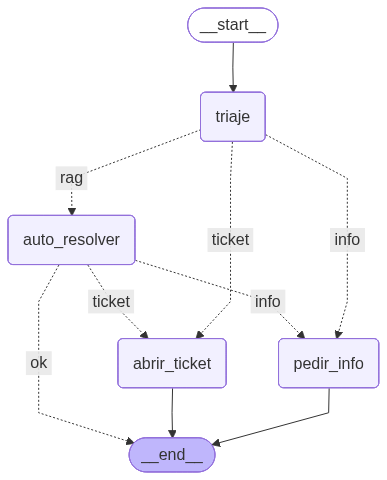

In [ ]:
from IPython.display import display, Image

graph_bytes = grafo.get_graph().draw_mermaid_png()
display(Image(graph_bytes))



In [ ]:
PREGUNTA = "¿Qué tipo de creadores pueden postularse al programa de afiliados?"

tempo = grafo.invoke({"pregunta": PREGUNTA})
print("")
print(f"PREGUNTA: {PREGUNTA}")
print(f"DECISION DE TRIAJE: {tempo['triaje']['decision']} | URGENCIA: {tempo['triaje']['urgencia']} | ACCIÓN FINAL: {tempo['accion_final']}")
print(f"RESPUESTA: {tempo['respuesta']}")
if tempo['citaciones']:
        for i, citacion in enumerate(tempo['citaciones']):
          print(f"  - CITACION {i + 1}:")
          print(f"    Camino del documento: {citacion.metadata['file_path']}")
          print(f"    Contenido: {citacion.page_content.replace('\n', ' ')}")